<a href="https://colab.research.google.com/github/TrevorGankarch/PdM-Using-AI-and-Machine-Learning/blob/main/IDV_presentation_PdM_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 28.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.9/264.9 kB 10.5 MB/s eta 0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytoscape-1.0.2-py3-none-any.whl size=40

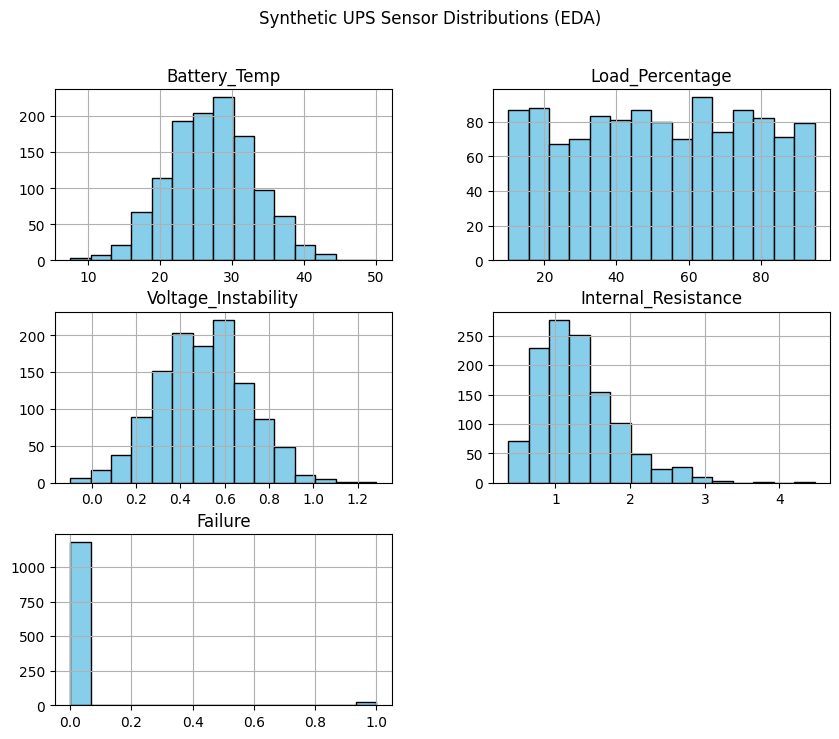


[PART 3] XGBoost Baseline AUC: 0.9692
[PART 4] Explainable GAM (EBM) AUC: 0.9827



[PART 5] Semantic Translation Layer Demo:
Signal: Battery_Temp (21.07) -> Status: Nominal
Signal: Internal_Resistance (0.81) -> Status: Nominal


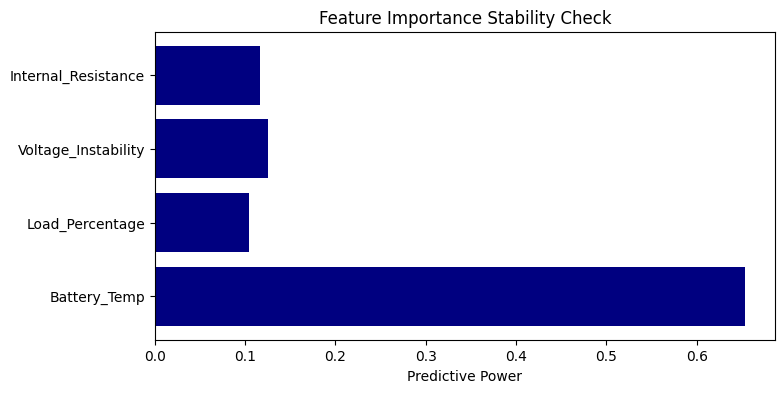

In [1]:
# ==========================================
# STEP 0: Install Requirements
# ==========================================
!pip install interpret xgboost pandas numpy matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show, preserve

# ==========================================
# PART 1 & 2: Data Generation & EDA
# ==========================================
def generate_ups_data(n_samples=1200):
    np.random.seed(42)
    # Features representative of Schneider Electric UPS systems
    temp = np.random.normal(27, 6, n_samples)          # Battery Temp
    load = np.random.uniform(10, 95, n_samples)        # Load %
    v_stability = np.random.normal(0.5, 0.2, n_samples) # Voltage fluctuation
    int_res = np.random.lognormal(0.2, 0.4, n_samples)  # Internal Resistance

    # Logic: Failure is driven by high temp + high resistance (Thermal Runaway)
    logit = (0.6 * (temp - 32)) + (1.2 * (int_res - 1.8)) + (0.02 * load) - 6
    prob = 1 / (1 + np.exp(-logit))
    failure = (prob > np.random.rand(n_samples)).astype(int)

    return pd.DataFrame({
        'Battery_Temp': temp,
        'Load_Percentage': load,
        'Voltage_Instability': v_stability,
        'Internal_Resistance': int_res,
        'Failure': failure
    })

df = generate_ups_data()
X = df.drop('Failure', axis=1)
y = df['Failure']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Show Data Distribution for the Video
df.hist(bins=15, figsize=(10, 8), color='skyblue', edgecolor='black')
plt.suptitle("Synthetic UPS Sensor Distributions (EDA)")
plt.show()

# ==========================================
# PART 3: Baseline Black-Box Model
# ==========================================
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

print(f"\n[PART 3] XGBoost Baseline AUC: {xgb_auc:.4f}")

# ==========================================
# PART 4: The 'Glass-Box' (GAM/FastSparse)
# ==========================================
# Using EBM (Explainable Boosting Machine) - the state-of-the-art GAM
ebm = ExplainableBoostingClassifier(random_state=42)
ebm.fit(X_train, y_train)
ebm_auc = roc_auc_score(y_test, ebm.predict_proba(X_test)[:, 1])

print(f"[PART 4] Explainable GAM (EBM) AUC: {ebm_auc:.4f}")

# IMPORTANT FOR VIDEO: This creates the interactive dashboard
ebm_global = ebm.explain_global(name='Global Explanations')
show(ebm_global)

# ==========================================
# PART 5: Semantic Translation (Rule-Based)
# ==========================================
def translate_to_engineering(feature, value):
    knowledge_base = {
        'Battery_Temp': (35, "Critical Thermal Stress"),
        'Internal_Resistance': (2.1, "High Internal Degradation"),
        'Voltage_Instability': (0.8, "Input Power Quality Issue")
    }
    if feature in knowledge_base:
        limit, msg = knowledge_base[feature]
        if value > limit: return f"DANGER: {msg}"
    return "Status: Nominal"

# Pick a high-risk sample to demonstrate
test_sample = X_test.iloc[0]
print(f"\n[PART 5] Semantic Translation Layer Demo:")
for feat in ['Battery_Temp', 'Internal_Resistance']:
    print(f"Signal: {feat} ({test_sample[feat]:.2f}) -> {translate_to_engineering(feat, test_sample[feat])}")

# ==========================================
# PART 6: Robustness Preview (Visualizing Shape Functions)
# ==========================================
# Manual plotting of a shape function to show in video if dashboard fails
plt.figure(figsize=(8, 4))
plt.barh(X.columns, xgb.feature_importances_, color='navy')
plt.title("Feature Importance Stability Check")
plt.xlabel("Predictive Power")
plt.show()